In [14]:
import pandas as pd
import sys
from tqdm import tqdm
import cv2
import os
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

sys.path.append('..')
import mlrose_hiive

In [78]:
ITERATIONS = 10
LR = 1e-9

# ITERATIONS = 50
# LR = 1e-10

# ITERATIONS = 100
# LR = 1e-11

# ITERATIONS = 500
# LR = 1e-11

MAX_ATTEMPTS = 1000
NUM_RUNS = 3
OUTPUT_DIR = f'metrics/iters={ITERATIONS}'
os.makedirs(OUTPUT_DIR, exist_ok=True)
LR_STR = f'1e{int(np.log10(LR))}'
DF_PATH = os.path.join(OUTPUT_DIR, f'sgd_lr={LR_STR}.csv')

In [79]:
train_df = pd.read_csv('../dataset/dataframes/train.csv')
test_df = pd.read_csv('../dataset/dataframes/test.csv')
train_df = train_df.sample(frac=1)
test_df = test_df.sample(frac=1)

In [80]:
len(train_df), len(test_df)

(960, 320)

In [81]:
def simplify_label(label):
    if 'a' in label or 'b' in label or 'c' in label or 'd' in label:
        return 'abcd'
    else:
        assert('e' in label or 'f' in label or 'g' in label or 'h' in label)
        return 'efgh'
train_df['label'] = train_df['label'].apply(simplify_label)
test_df['label'] = test_df['label'].apply(simplify_label)

In [82]:
SIZE = 256
train_image_list = []
train_class_list = []
for i, row in train_df.iterrows():
    img = cv2.imread(row['path'])
    # resize the image
    img = cv2.resize(img, (SIZE, SIZE))
    train_image_list.append(img)
    train_class_list.append(row['label'])
X_train = np.array(train_image_list)
X_train = X_train.reshape(X_train.shape[0], -1)

test_image_list = []
test_class_list = []
for i, row in test_df.iterrows():
    img = cv2.imread(row['path'])
    # resize the image
    img = cv2.resize(img, (SIZE, SIZE))
    test_image_list.append(img)
    test_class_list.append(row['label'])
X_test = np.array(test_image_list)
X_test = X_test.reshape(X_test.shape[0], -1)

In [83]:
one_hot = OneHotEncoder()
one_hot.fit(np.array(train_class_list).reshape(-1, 1))
y_train = one_hot.transform(np.array(train_class_list).reshape(-1, 1)).toarray()
y_test = one_hot.transform(np.array(test_class_list).reshape(-1, 1)).toarray()

In [84]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((960, 3072), (320, 3072), (960, 2), (320, 2))

In [85]:
nn_model = mlrose_hiive.NeuralNetwork(
    hidden_nodes=[], 
    activation='relu',
    algorithm='gradient_descent', 
    max_iters=ITERATIONS,
    bias=True, 
    is_classifier=True, 
    learning_rate=LR,
    early_stopping=True, 
    # clip_max=5, 
    max_attempts=MAX_ATTEMPTS,
    random_state=0,
    curve=True,
)

# shuffle the data
np.random.seed(0)
m = np.random.permutation(X_train.shape[0])
X_train = X_train[m]
y_train = y_train[m]

nn_model.fit(X_train, y_train)

# Predict labels for train set and assess accuracy
y_train_pred = nn_model.predict(X_train)
y_train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"y_train_accuracy: {y_train_accuracy}")

unique_predictions = np.unique(y_train_pred)
n1 = sum(y_train_pred == unique_predictions[0])
n2 = sum(y_train_pred == unique_predictions[1])
print(f"Number of predictions in y_train_pred: {n1}, {n2}")

y_test_pred = nn_model.predict(X_test)
y_test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"y_test_accuracy: {y_test_accuracy}")

y_train_accuracy: 0.51875
Number of predictions in y_train_pred: [538 422], [422 538]
y_test_accuracy: 0.490625


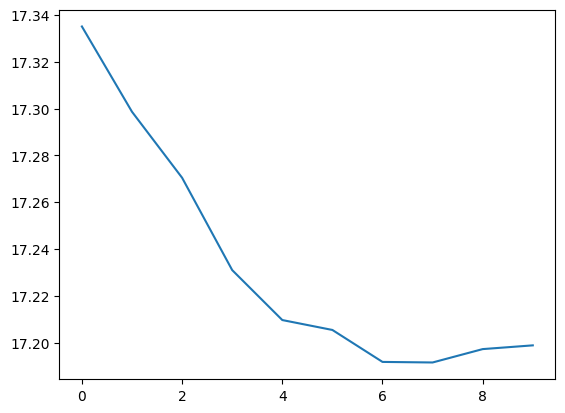

In [86]:
plt.plot(nn_model.fitness_curve)
# nn_model.fitness_curve

In [ ]:
import time
data = {'run_number': [], 'curve': [], 'y_train_accuracy': [], 'y_test_accuracy': [], 'total_time': []}
for run_i in tqdm(range(NUM_RUNS)):
    t0 = time.perf_counter()
    nn_model = mlrose_hiive.NeuralNetwork(
        hidden_nodes=[], 
        activation='relu',
        algorithm='gradient_descent', 
        max_iters=ITERATIONS,
        bias=True, 
        is_classifier=True, 
        learning_rate=LR,
        early_stopping=True, 
        # clip_max=5, 
        max_attempts=MAX_ATTEMPTS,
        random_state=run_i,
        curve=True,
    )

    # shuffle the data
    np.random.seed(run_i)
    m = np.random.permutation(X_train.shape[0])
    X_train = X_train[m]
    y_train = y_train[m]

    nn_model.fit(X_train, y_train)
    t1 = time.perf_counter()
    total_time = t1 - t0

    # Predict labels for train set and assess accuracy
    y_train_pred = nn_model.predict(X_train)
    y_train_accuracy = accuracy_score(y_train, y_train_pred)
    print(f"y_train_accuracy: {y_train_accuracy}")

    unique_predictions = np.unique(y_train_pred)
    n1 = sum(y_train_pred == unique_predictions[0])
    n2 = sum(y_train_pred == unique_predictions[1])
    print(f"Number of predictions in y_train_pred: {n1}, {n2}")

    y_test_pred = nn_model.predict(X_test)
    y_test_accuracy = accuracy_score(y_test, y_test_pred)
    print(f"y_test_accuracy: {y_test_accuracy}")

    data['run_number'].append(run_i)
    data['curve'].append(nn_model.fitness_curve)
    data['y_train_accuracy'].append(y_train_accuracy)
    data['y_test_accuracy'].append(y_test_accuracy)
    data['total_time'].append(total_time)
df = pd.DataFrame(data)

In [ ]:
df.to_csv(DF_PATH, index=False)